In [82]:
from grecco_sim.data import simbench_data
from pathlib import Path
import pandas as pd


data_root = Path("/home/carl-wanninger/data")
simbench_path = data_root / "simbench_csv" / "all_profiles_2034"

simbench = simbench_data.SimBenchData(simbench_path)

4 duplicates in RESProfile.csv were averaged. 
4 duplicates in LoadProfile.csv were averaged. 
4 duplicates in StorageProfile.csv were averaged. 


In [91]:
hh_tags = ["H0-A", "H0-B", "H0-C"]

data = simbench.load_t[[f"{x}_pload" for x in hh_tags]]
data["time"] = pd.DatetimeIndex(data.index)
data = data.melt(id_vars=["time"], value_vars=[f"{x}_pload" for x in hh_tags], var_name="profile", value_name="pload")

/tmp/ipykernel_1865/4277287098.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["time"] = pd.DatetimeIndex(data.index)


/tmp/ipykernel_1865/2025039950.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_1["pload"] *= 3
/tmp/ipykernel_1865/2025039950.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_1["profile"] = data_1["profile"].str.strip("_pload")


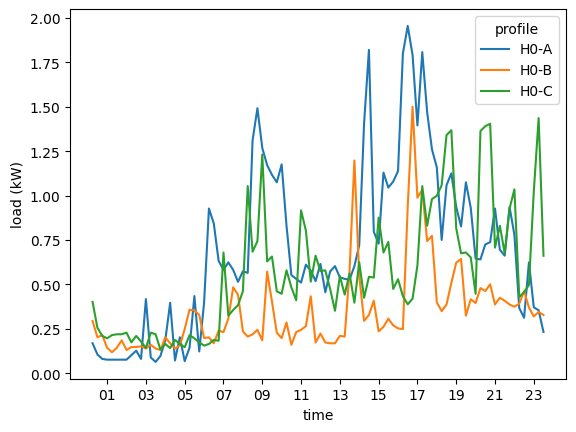

In [99]:
import seaborn as sns
from grecco_sim.util import plot
import matplotlib.pyplot as plt

data_1 = data.query("'2016-01-13 00:00' < time < '2016-01-13 23:45'")
fig, ax = plt.subplots()
ax = plot.set_two_hours_x_axis(ax)
data_1["pload"] *= 3
data_1["profile"] = data_1["profile"].str.strip("_pload")
sns.lineplot(data=data_1,x="time", y="pload", hue="profile", ax=ax)
ax.set_ylabel("load (kW)")
p = Path("") / "plots" / "H0-sample.png"
plt.savefig(p)

In [75]:
data.index

RangeIndex(start=0, stop=175660, step=1)